#Treinamento YOLOv8, YOLOv11 e YOLOv12

Notebook feito para rodar no **Google Colab** com GPU (`Ambiente de execução` → `Alterar o tipo de ambiente de execução` → `GPU`).

Fluxo deste notebook:

1. Configurações Iniciais e do Ambiente
2. Dowload do Dataset
3. Rotulação
4. Checagem Visual
5. Treinamento
6. Métricas geradas pelo treinamento
7. Recarregar o melhor checkpoint
8. Validação formal com o model.val()
9. Métricas de IoU

##Yolo

###1. Configurações Iniciais e do Ambiente

####Ambiente

Confirme que a GPU está ativa. Se a célula abaixo não mostrar uma GPU, vá em `Ambiente de execução` → `Alterar o tipo de ambiente de execução` e selecione `GPU` antes de continuar.

In [3]:
!nvidia-smi

Tue Sep 29 17:39:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!pip install ultralytics -q

import ultralytics
ultralytics.checks()

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (8 CPUs, 51.0 GB RAM, 47.4/235.7 GB disk)


####Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
%cd "/content/drive/MyDrive/LuisPedro"

/content/drive/MyDrive/LuisPedro


###2. Dowload do Dataset


Para essa parte, temos três opções ( A,B e C ), utilize-as conforme necessário.

In [ ]:
# OPÇÃO A: download direto via SDK do Roboflow
!pip install roboflow -q

from roboflow import Roboflow

rf = Roboflow(api_key="pgsba37snI4sRIOJmXO1")  # Roboflow -> Settings -> API Keys
project = rf.workspace("luiss-workspace-fyuhr").project("pistas-clandestinas-google-earth-tcz39")
dataset = project.version(1).download("yolov8")  # ajuste o número da versão

DATASET_DIR = dataset.location
print("Dataset baixado em:", DATASET_DIR)

In [ ]:
# OPÇÃO A: download direto via SDK do Roboflow
!pip install roboflow -q

from roboflow import Roboflow

rf = Roboflow(api_key="ROBOFLOW_API_KEY_LUIS")  # Roboflow -> Settings -> API Keys
project = rf.workspace("luiss-workspace-fyuhr").project("dataset-ic")
dataset = project.version(1).download("yolov8")  # ajuste o número da versão

DATASET_DIR = dataset.location
print("Dataset baixado em:", DATASET_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 126.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.7 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Dataset---IC-1 in yolov8:: 100%|██████████| 1491/1491 [00:48<00:00, 30.68it/s] 


Dataset baixado em: /content/drive/MyDrive/LuisPedro/Dataset---IC-1


In [16]:
# OPÇÃO A: download direto via SDK do Roboflow
!pip install roboflow -q

from google.colab import userdata
from roboflow import Roboflow

api_key = userdata.get("ROBOFLOW_API_KEY")
rf = Roboflow(api_key=api_key)
project = rf.workspace("luiss-workspace-fyuhr").project("dataset-ic-redimensionado")
dataset = project.version(4).download("yolov8")  # ajuste o número da versão

DATASET_DIR = dataset.location
print("Dataset baixado em:", DATASET_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.6 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Dataset---IC---Redimensionado-4 in yolov8:: 100%|██████████| 2945/2945 [00:20<00:00, 141.49it/s]

Dataset baixado em: /content/drive/MyDrive/LuisPedro/Dataset---IC---Redimensionado-4


In [ ]:
# OPÇÃO B: upload manual do .zip exportado pelo Roboflow
# (descomente e use esta célula em vez da anterior, se preferir)

# from google.colab import files
# uploaded = files.upload()  # selecione o .zip exportado no formato YOLOv8
#
# import zipfile
#
# zip_name = list(uploaded.keys())[0]
# DATASET_DIR = "/content/dataset"
# with zipfile.ZipFile(zip_name, "r") as zip_ref:
#     zip_ref.extractall(DATASET_DIR)
#
# print("Dataset extraído em:", DATASET_DIR)

In [ ]:
# OPÇÃO C: dataset já está em uma pasta do seu Google Drive
# (pule as opções A e B se você já tem o dataset organizado, ex. em
# /content/drive/MyDrive/... — só ajuste o caminho abaixo)

#DATASET_DIR = "/content/drive/MyDrive/LuisPedro/pistaClandetinas"  # <-- ajuste aqui
#print("Usando dataset em:", DATASET_DIR)

###3. Rotulação

In [18]:
import os

# Caminho do dataset
BASE_DIR = "/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness"

yaml_path = os.path.join(BASE_DIR, "data.yaml")

yaml_content = f"""names:
- pistas
nc: 1
train: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images
val: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/valid/images
test: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"data.yaml atualizado em: {yaml_path}")
print(yaml_content)

data.yaml atualizado em: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/data.yaml
names:
- pistas
nc: 1
train: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images
val: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/valid/images
test: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images



In [19]:
import os

DATASET_DIR = "/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness"

print(os.listdir(DATASET_DIR))

['train', 'valid', 'test', 'README.roboflow.txt', 'README.dataset.txt', 'data.yaml']


In [20]:
import os, glob, yaml

# Se você reiniciou o ambiente de execução e pulou a Seção 2, esta linha
# evita um NameError -- mas ajuste o caminho se DATASET_DIR ainda não existir.
if "DATASET_DIR" not in globals():
    DATASET_DIR = "/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness"  # <-- ajuste

data_yaml_path = os.path.join(DATASET_DIR, "data.yaml")

with open(data_yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

print(data_cfg)

for split in ["train", "val", "test"]:
    if split in data_cfg:
        # Roboflow costuma usar caminhos relativos, ex: '../train/images'
        full_path = os.path.normpath(os.path.join(DATASET_DIR, data_cfg[split]))
        n_imgs = len(glob.glob(os.path.join(full_path, "*.*"))) if os.path.exists(full_path) else 0
        print(f"{split}: {full_path} -> {n_imgs} imagens")

{'names': ['pistas'], 'nc': 1, 'train': '/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images', 'val': '/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/valid/images', 'test': '/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images'}
train: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images -> 73 imagens
val: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/valid/images -> 178 imagens
test: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images -> 73 imagens


###4. Checagem Visual

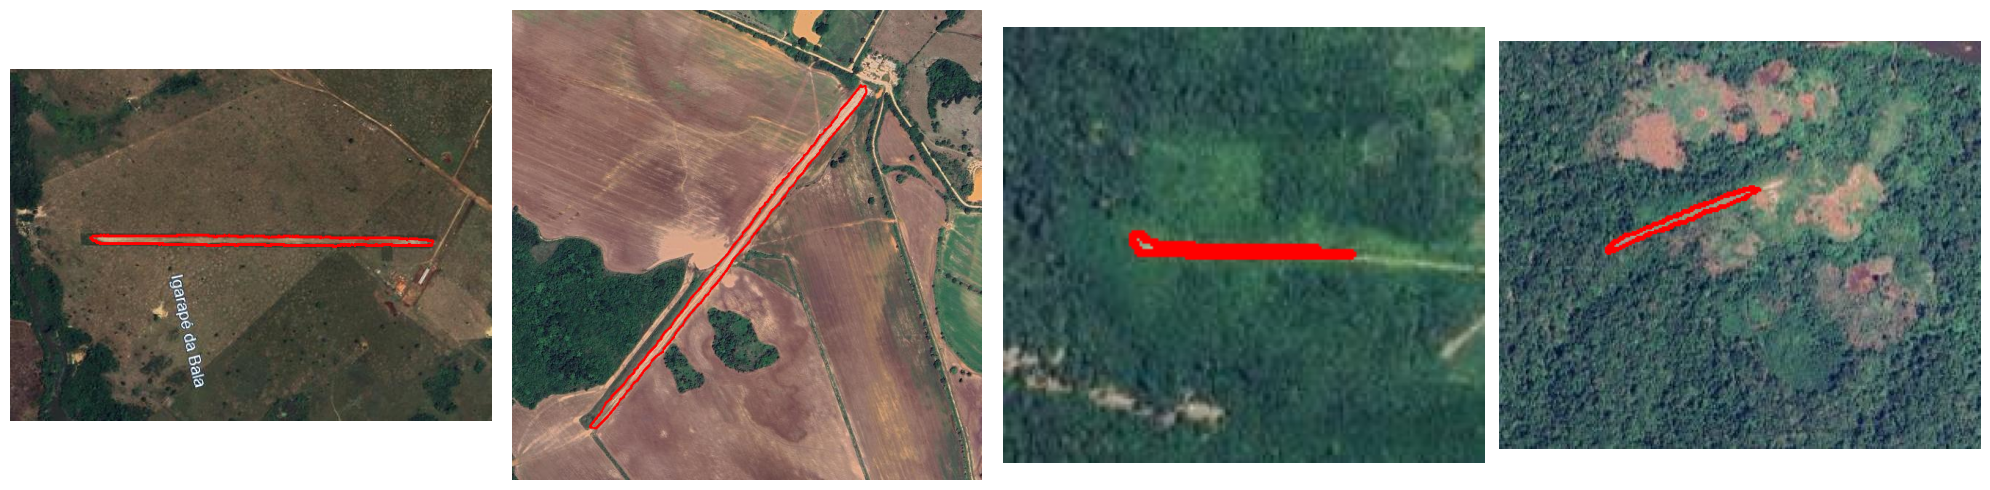

In [21]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt


def desenhar_labels(img_path, label_path, ax):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                values = line.strip().split()
                if not values:
                    continue
                coords = list(map(float, values[1:]))
                pts = np.array(
                    [(coords[i] * w, coords[i + 1] * h) for i in range(0, len(coords), 2)],
                    dtype=np.int32,
                )
                cv2.polylines(img, [pts], isClosed=True, color=(255, 0, 0), thickness=2)

    ax.imshow(img)
    ax.axis("off")


train_images_dir = os.path.normpath(os.path.join(DATASET_DIR, data_cfg["train"]))
train_labels_dir = train_images_dir.replace("images", "labels")

imgs = sorted(glob.glob(os.path.join(train_images_dir, "*.*")))
amostras = random.sample(imgs, min(4, len(imgs)))

fig, axes = plt.subplots(1, len(amostras), figsize=(5 * len(amostras), 5))
if len(amostras) == 1:
    axes = [axes]

for img_path, ax in zip(amostras, axes):
    label_path = os.path.join(train_labels_dir, os.path.splitext(os.path.basename(img_path))[0] + ".txt")
    desenhar_labels(img_path, label_path, ax)

plt.tight_layout()
plt.show()

###5. Treinamento


####YOLOv8

In [22]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")  # Modelos: n/s/m/l/x

results = model.train(
    data=os.path.join(DATASET_DIR, "data.yaml"),
    epochs=600,
    imgsz=640,
    batch=8,
    patience=90,
    project="/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness",
    name="treino_yolov8_seg-n_v3_brightness_8batch",
)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=600, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=

####YOLOv11

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11x-seg.pt")  # Modelos: n/s/m/l/x

results = model.train(
    data=os.path.join(DATASET_DIR, "data.yaml"),
    epochs=600,
    imgsz=640,
    batch=8,
    patience=90,
    project="/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v1",
    name="treino_yolov11_seg-x_v1",
)

####YOLOv12

In [ ]:
from ultralytics import YOLO
import os

model = YOLO("yolo12l-seg.yaml") # Modelos: n/s/m/l/x

results = model.train(
    data=os.path.join(DATASET_DIR, "data.yaml"),
    epochs=600,
    imgsz=640,
    batch=8,
    patience=90,
    project="/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v1",
    name="treino_yolov12_seg-l_v1",
)

Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=600, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12l-seg.yaml, momentum=0.937, mosai

###6. Métricas geradas pelo treinamento

Dentro de `runs/segment/treino_yolov8_seg/` o Ultralytics já salva:

- `results.csv` / `results.png`: curvas de loss, precisão, recall e mAP por época
- `confusion_matrix.png`: matriz de confusão
- `val_batch*_pred.jpg`: exemplos de predição no conjunto de validação

Vamos exibir o `results.png` para uma primeira leitura visual do treino.

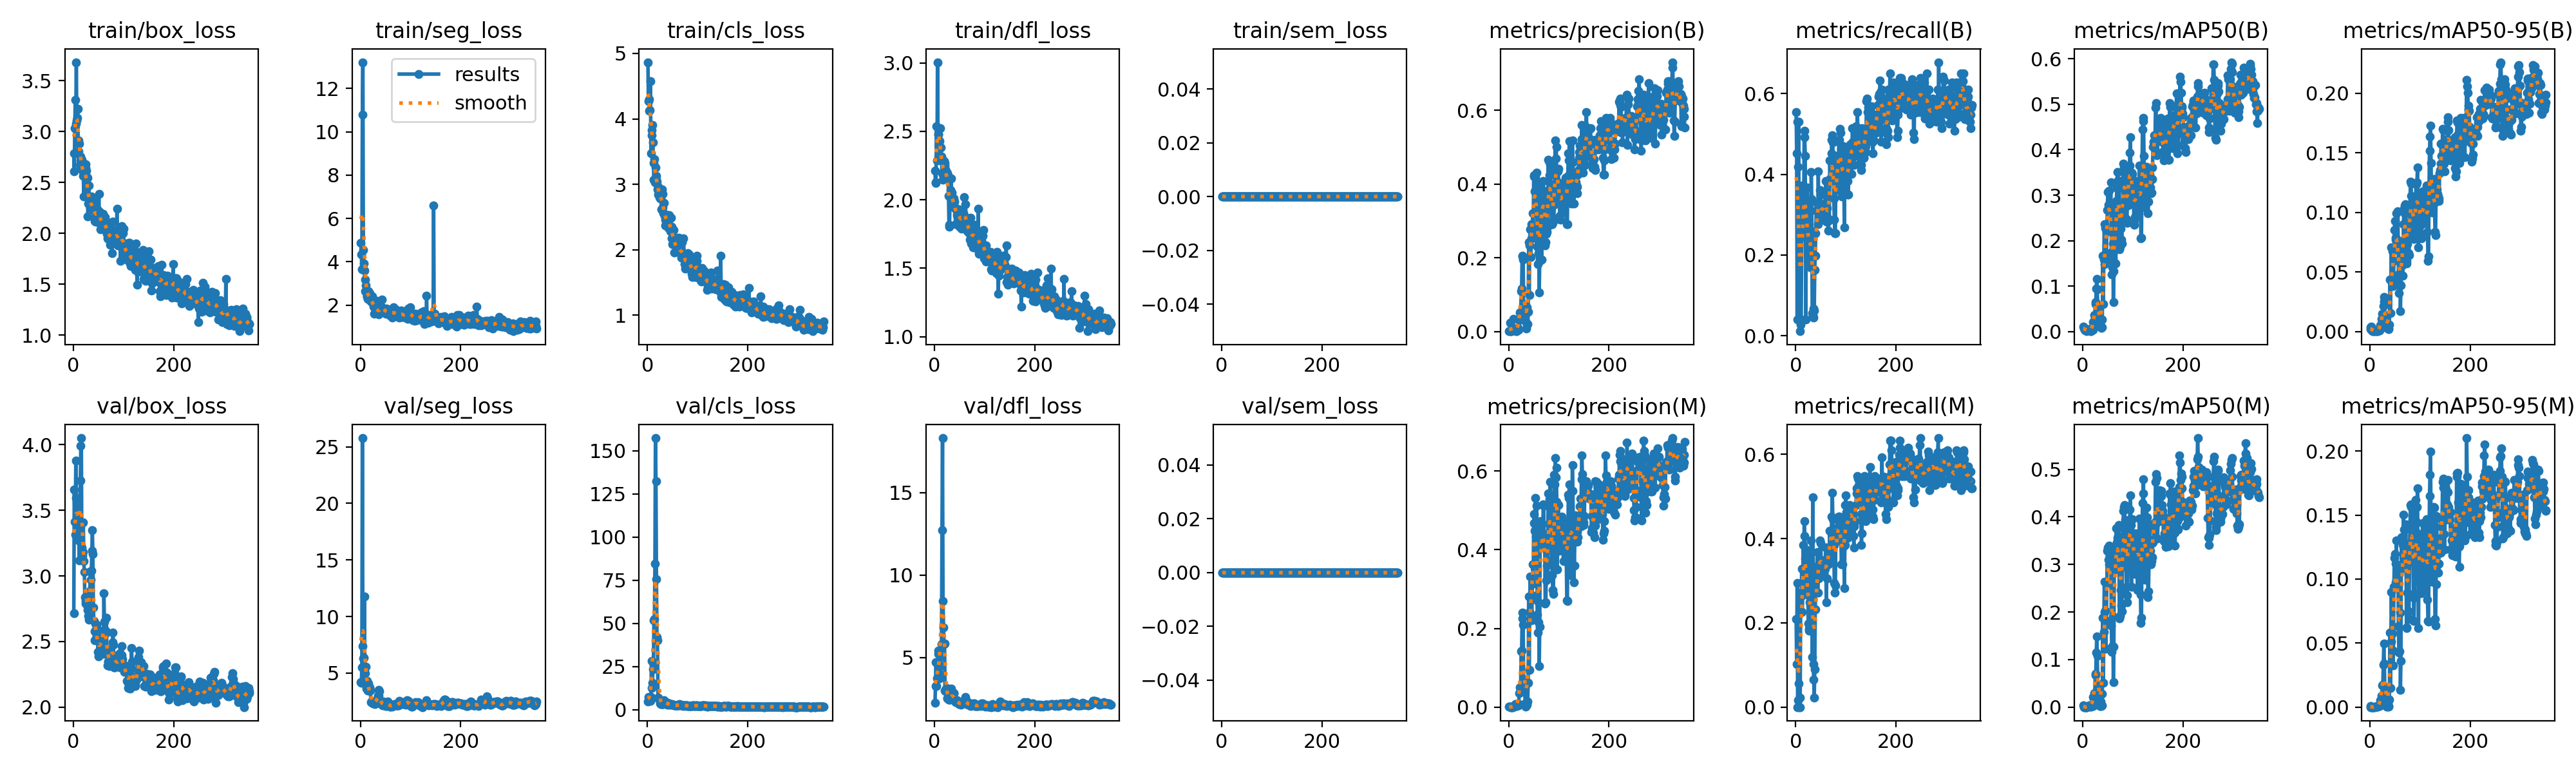

In [24]:
from IPython.display import Image, display

display(Image(filename="/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/treino_yolov8_seg-n_v3_brightness_8batch/results.png"))

###7. Recarregar o melhor checkpoint (best.pt)


In [25]:
from ultralytics import YOLO

BEST_WEIGHTS = "/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/treino_yolov8_seg-n_v3_brightness_8batch/weights/best.pt"
model = YOLO(BEST_WEIGHTS)
print("Modelo carregado de:", BEST_WEIGHTS)

Modelo carregado de: /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/treino_yolov8_seg-n_v3_brightness_8batch/weights/best.pt


###8. Validação formal com `model.val()`

Roda a validação oficial do Ultralytics, retornando mAP de caixa (box) e de máscara (seg) em vários limiares de IoU. Internamente o Ultralytics já usa IoU para decidir se uma predição "bate" com o rótulo verdadeiro, mas não expõe um "IoU médio simples" por imagem — isso vem na próxima seção.

In [26]:
import os

if "DATASET_DIR" not in globals():
    DATASET_DIR = "/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness"  # <-- ajuste

metrics = model.val(data=os.path.join(DATASET_DIR, "data.yaml"), split="test")

print("== Métricas de detecção (caixas) ==")
print(f"mAP50-95 (box): {metrics.box.map:.4f}")
print(f"mAP50    (box): {metrics.box.map50:.4f}")

print("\n== Métricas de segmentação (máscaras) ==")
print(f"mAP50-95 (mask): {metrics.seg.map:.4f}")
print(f"mAP50    (mask): {metrics.seg.map50:.4f}")

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.1 ms, read: 26.2±14.5 MB/s, size: 25.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/labels.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 20.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.3it/s 2.2s
                   all         73         73       0.87      0.823       0.93      0.643      0.884      0.836      0.942      0.559
Speed: 3.0ms preprocess, 5.7ms inference, 0.0ms loss, 3.5ms postprocess per image
Results save

###9. Métrica de IoU

In [27]:
# ============================================================
# CÉLULA 1 — Imports e funções de conversão de anotação
# ============================================================
import numpy as np
import cv2
from pathlib import Path
from ultralytics import YOLO


def parse_yolo_segmentation_label(label_path):
    """
    Lê um .txt no formato YOLO-segmentação:
        class x1 y1 x2 y2 x3 y3 ... xn yn  (normalizado em [0,1])
    Retorna lista de polígonos (cada um é um array de pontos).
    Importante: isso NÃO é o formato de detecção (5 valores fixos) —
    é um polígono com número variável de pontos.
    """
    polygons = []
    if not Path(label_path).exists():
        return polygons

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:  # classe + pelo menos 3 pontos
                continue
            coords = list(map(float, parts[1:]))
            poly = np.array(coords, dtype=np.float32).reshape(-1, 2)
            polygons.append(poly)
    return polygons


def polygon_to_bbox(polygon_norm, img_w, img_h):
    """Caixa envolvente (min/max) de um polígono normalizado."""
    poly_px = polygon_norm.copy()
    poly_px[:, 0] *= img_w
    poly_px[:, 1] *= img_h
    x1, y1 = poly_px[:, 0].min(), poly_px[:, 1].min()
    x2, y2 = poly_px[:, 0].max(), poly_px[:, 1].max()
    return np.array([x1, y1, x2, y2])


def polygon_to_mask(polygon_norm, img_w, img_h):
    """Rasteriza um polígono normalizado em máscara binária."""
    poly_px = polygon_norm.copy()
    poly_px[:, 0] *= img_w
    poly_px[:, 1] *= img_h
    poly_px = poly_px.astype(np.int32)

    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(mask, [poly_px], 1)
    return mask


def compute_iou_bbox(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def compute_iou_mask(mask_a, mask_b):
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return inter / union if union > 0 else 0.0


# ============================================================
# CÉLULA 2 — Pareamento guloso (com diagnóstico dos FN)
# ============================================================
def greedy_match(iou_matrix, iou_threshold=0.5):
    n_pred, n_gt = iou_matrix.shape
    if n_gt == 0:
        return [], n_pred, 0, []
    if n_pred == 0:
        return [], 0, n_gt, [0.0] * n_gt

    pairs = [(i, j, iou_matrix[i, j]) for i in range(n_pred) for j in range(n_gt)]
    pairs.sort(key=lambda x: x[2], reverse=True)

    used_p, used_g, matched = set(), set(), []
    for i, j, val in pairs:
        if i in used_p or j in used_g:
            continue
        if val < iou_threshold:
            break
        matched.append(val)
        used_p.add(i)
        used_g.add(j)

    fp = n_pred - len(used_p)
    fn = n_gt - len(used_g)

    # Para os GTs que ficaram como FN: qual foi o melhor IoU que tiveram
    # com alguma predição, mesmo abaixo do threshold (só diagnóstico).
    best_unmatched_gt_iou = []
    for j in range(n_gt):
        if j in used_g:
            continue
        best = iou_matrix[:, j].max() if n_pred > 0 else 0.0
        best_unmatched_gt_iou.append(best)

    return matched, fp, fn, best_unmatched_gt_iou


# ============================================================
# CÉLULA 3 — Predição no dataset v3
# ============================================================
# AJUSTE aqui: caminho do seu checkpoint treinado no v3
model = YOLO("/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/treino_yolov8_seg-n_v3_brightness_8batch/weights/best.pt")

images_dir = Path("/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images")
labels_dir = images_dir.parent / "labels"

results = model.predict(source=str(images_dir), conf=0.25, save=True)


# ============================================================
# CÉLULA 4 — Avaliação (separando "todas" de "só com pista real")
# ============================================================
bbox_ious, mask_ious = [], []
bbox_ious_com_pista, mask_ious_com_pista = [], []  # só onde há GT de verdade
fp_bbox_total = fn_bbox_total = 0
fp_mask_total = fn_mask_total = 0

for r in results:
    img_h, img_w = r.orig_shape
    img_name = Path(r.path).stem
    label_path = labels_dir / f"{img_name}.txt"

    gt_polygons = parse_yolo_segmentation_label(label_path)
    gt_bboxes = [polygon_to_bbox(p, img_w, img_h) for p in gt_polygons]
    gt_masks = [polygon_to_mask(p, img_w, img_h) for p in gt_polygons]  # SEMPRE calculado
    tem_pista_real = len(gt_polygons) > 0

    pred_bboxes = r.boxes.xyxy.cpu().numpy() if r.boxes is not None else np.empty((0, 4))
    if r.masks is not None:
        pred_masks_raw = r.masks.data.cpu().numpy()
        pred_masks = [cv2.resize(m, (img_w, img_h), interpolation=cv2.INTER_NEAREST).astype(np.uint8)
                      for m in pred_masks_raw]
    else:
        pred_masks = []

    # --- Bounding box ---
    iou_mat_bbox = np.array([[compute_iou_bbox(pb, gb) for gb in gt_bboxes] for pb in pred_bboxes]) \
                   if len(pred_bboxes) and len(gt_bboxes) else np.zeros((len(pred_bboxes), len(gt_bboxes)))
    matched, fp, fn, _ = greedy_match(iou_mat_bbox, iou_threshold=0.5)
    bbox_ious.extend(matched)
    fp_bbox_total += fp
    fn_bbox_total += fn
    if tem_pista_real:
        bbox_ious_com_pista.extend(matched)

    # --- Máscara ---
    iou_mat_mask = np.array([[compute_iou_mask(pm, gm) for gm in gt_masks] for pm in pred_masks]) \
                   if len(pred_masks) and len(gt_masks) else np.zeros((len(pred_masks), len(gt_masks)))
    matched_m, fp_m, fn_m, _ = greedy_match(iou_mat_mask, iou_threshold=0.5)
    mask_ious.extend(matched_m)
    fp_mask_total += fp_m
    fn_mask_total += fn_m
    if tem_pista_real:
        mask_ious_com_pista.extend(matched_m)


# ============================================================
# CÉLULA 5 — Verificação de consistência (não pula essa etapa!)
# ============================================================
total_gt_bbox = len(bbox_ious) + fn_bbox_total
total_gt_mask = len(mask_ious) + fn_mask_total
print(f"Total de GT (bbox): {total_gt_bbox} | Total de GT (máscara): {total_gt_mask}")
assert total_gt_bbox == total_gt_mask, "ERRO: os totais não batem — não confie nos números abaixo."
print("OK: os totais batem.\n")


# ============================================================
# CÉLULA 6 — Relatório final
# ============================================================
def report(name, ious_todas, ious_com_pista, fp, fn):
    ious_todas = np.array(ious_todas)
    ious_com_pista = np.array(ious_com_pista)
    print(f"--- {name} ---")
    print(f"TP: {len(ious_todas)} | FP: {fp} | FN: {fn}")
    if len(ious_todas) > 0:
        print(f"IoU médio (todas as imagens): {ious_todas.mean():.4f}")
    if len(ious_com_pista) > 0:
        print(f"IoU médio (só imagens com pista real): {ious_com_pista.mean():.4f}")
    print()

report("Bounding Box", bbox_ious, bbox_ious_com_pista, fp_bbox_total, fn_bbox_total)
report("Máscara (pixel a pixel)", mask_ious, mask_ious_com_pista, fp_mask_total, fn_mask_total)


image 1/73 /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images/005_png.rf.f6cda7d957842ae2f5b27f09ebcc10e6.jpg: 320x640 3 pistass, 9.3ms
image 2/73 /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images/006_png.rf.066bc408b77ca4d319d50fc115d75746.jpg: 512x640 1 pistas, 12.1ms
image 3/73 /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images/012_png.rf.db165389b52ac18179488380888eaaa7.jpg: 384x640 1 pistas, 11.8ms
image 4/73 /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images/0219_png.rf.4bae04717df35ff8db1cc901d6bd22a8.jpg: 608x640 1 pistas, 12.0ms
image 5/73 /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness/test/images/0227_png.rf.cf3729887cceaa5b35089cbd56f86b6d.jpg: 608x640 1 pistas, 10.4ms
image 6/73 /content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth

In [7]:
import os
import cv2
import numpy as np


def label_to_mask(label_path, img_shape, class_filter=None):
    """
    Constrói uma máscara binária a partir de um rótulo YOLOv8-seg (Roboflow).

    label_path : caminho do arquivo .txt de rótulo (uma linha por instância:
                 class_id x1 y1 x2 y2 ... xn yn, coordenadas normalizadas 0-1)
    img_shape  : (altura, largura) da imagem correspondente
    class_filter : int, lista de ints, ou None.
                   Se None, todas as classes são combinadas numa única máscara
                   binária (foreground x fundo). Se informado, só as instâncias
                   dessa(s) classe(s) entram na máscara.
    """
    h, w = img_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    if not os.path.exists(label_path):
        return mask  # imagem sem nenhuma instância anotada

    with open(label_path, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    classes_aceitas = None
    if class_filter is not None:
        classes_aceitas = [class_filter] if isinstance(class_filter, int) else list(class_filter)

    for line in lines:
        values = line.split()
        class_id = int(float(values[0]))
        coords = list(map(float, values[1:]))

        if classes_aceitas is not None and class_id not in classes_aceitas:
            continue

        pts = np.array(
            [(coords[i] * w, coords[i + 1] * h) for i in range(0, len(coords), 2)],
            dtype=np.int32,
        )
        cv2.fillPoly(mask, [pts], 1)

    return mask


def predict_mask(model, image_path, conf=0.25, class_filter=None):
    """
    Roda a inferência do modelo treinado numa imagem e devolve uma máscara
    binária (0/1) já no tamanho original da imagem, combinando todas as
    instâncias detectadas (ou só as da(s) classe(s) em class_filter).
    """
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    results = model.predict(image_path, conf=conf, verbose=False)
    r = results[0]

    if r.masks is None:
        return mask  # nenhuma instância detectada

    classes_aceitas = None
    if class_filter is not None:
        classes_aceitas = [class_filter] if isinstance(class_filter, int) else list(class_filter)

    for i, polygon in enumerate(r.masks.xy):  # já em coordenadas de pixel da imagem original
        if classes_aceitas is not None:
            cls_id = int(r.boxes.cls[i].item())
            if cls_id not in classes_aceitas:
                continue
        pts = polygon.astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)

    return mask


def calculate_iou(mask_a, mask_b):
    """
    IoU (Intersection over Union) entre duas máscaras binárias do mesmo tamanho.
    Quando união == 0 (as duas máscaras vazias), retorna 1.0 em vez de NaN.
    """
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    if union == 0:
        return 1.0
    return intersection / union

In [9]:
import os, glob, yaml
import cv2
import numpy as np
import pandas as pd

if "DATASET_DIR" not in globals():
    DATASET_DIR = "/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_flip"  # <-- ajuste

if "data_cfg" not in globals():
    with open(os.path.join(DATASET_DIR, "data.yaml"), "r") as f:
        data_cfg = yaml.safe_load(f)

# IMPORTANTE: SPLIT é a CHAVE do data.yaml ('train', 'val' ou 'test'),
# não um caminho -- o caminho completo é montado logo abaixo a partir
# de DATASET_DIR + data_cfg[SPLIT]. Não coloque um path aqui.
SPLIT = "test"
if SPLIT not in data_cfg:
    SPLIT = "valid" if "valid" in data_cfg else list(data_cfg.keys())[0]

split_images_dir = os.path.join(DATASET_DIR, SPLIT, "images")
split_labels_dir = os.path.join(DATASET_DIR, SPLIT, "labels")

print(split_images_dir)
print(os.path.exists(split_images_dir))
print(len(glob.glob(os.path.join(split_images_dir, "*.jpg"))))

image_paths = sorted(glob.glob(os.path.join(split_images_dir, "*.*")))

resultados = []
for img_path in image_paths:
    filename = os.path.basename(img_path)
    label_path = os.path.join(split_labels_dir, os.path.splitext(filename)[0] + ".txt")

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    gt_mask = label_to_mask(label_path, (h, w))
    pred_mask = predict_mask(model, img_path, conf=0.25)

    iou = calculate_iou(gt_mask, pred_mask)
    resultados.append({"imagem": filename, "iou": iou})

df_iou = pd.DataFrame(resultados)
mean_iou = df_iou["iou"].mean()

print(df_iou)
print(f"\nIoU médio no split '{SPLIT}': {mean_iou:.4f}")

output_csv = os.path.join(DATASET_DIR, f"iou_{SPLIT}.csv")
df_iou.to_csv(output_csv, index=False)
print(f"Resultados salvos em: {output_csv}")

/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_flip/test/images
True
73


NameError: name 'model' is not defined

##Outros Códigos

####Tirar o zip de uma pasta

In [ ]:
!unzip "/content/drive/MyDrive/LuisPedro/Pista Clandestina/Dataset (original)-20260727T164545Z-1-001 1.zip"

####Deletar uma pasta

In [ ]:
import shutil

folder = "/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3/treino_yolov8_seg-n_v3"

shutil.rmtree(folder)

print("Pasta deletada!")

Pasta deletada!


####Renomear uma pasta

In [17]:
import os

old_path = "/content/drive/MyDrive/LuisPedro/Dataset---IC---Redimensionado-4"
new_path = "/content/drive/MyDrive/LuisPedro/pistaClandestina/datasets/google_earth_v3_brightness"

os.rename(old_path, new_path)

print("Pasta renomeada com sucesso!")

Pasta renomeada com sucesso!
